### Parellisation

In [30]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"

llm = init_chat_model(model="google_genai:gemini-2.0-flash")

In [31]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [32]:
# Graph state
class State(TypedDict):
    topic: str
    syllabus: str
    content: str
    code: str
    combined_output: str


In [33]:
# Nodes
def call_llm_1(state: State):
    """First LLM call to generate a Table of Content (syllabus) on the topic"""
    msg = llm.invoke(f"Write a 2-hour training syllabus on: {state['topic']}")
    return {"syllabus": msg.content}

def call_llm_2(state: State):
    """Second LLM call to generate content explanation on each"""
    msg = llm.invoke(f"Write training content on {state['topic']} for 2 hours. Include tech and non-tech examples.")
    return {"content": msg.content}

def call_llm_3(state: State):
    """Third LLM call to generate Python demo"""
    msg = llm.invoke(f"Write a very simple Python demo using Hugging Face on: {state['topic']}")
    return {"code": msg.content}

def aggregator(state: State):
    """Combine all generated elements into one output"""
    combined = f"# Training Package for: {state['topic']}\n\n"
    combined += f"## Syllabus\n{state['syllabus']}\n\n"
    combined += f"## Content\n{state['content']}\n\n"
    combined += f"## Python Demo\n```python\n{state['code']}\n```\n"
    return {"combined_output": combined}


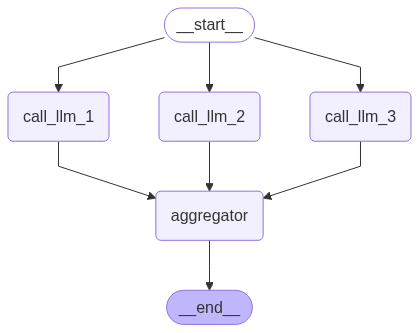

In [34]:
# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

# Compile and visualize
parallel_workflow = parallel_builder.compile()
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))


In [35]:
# Invoke
state = parallel_workflow.invoke({"topic": "Introduction to LLMs"})
print(state["combined_output"])

# Training Package for: Introduction to LLMs

## Syllabus
## Introduction to Large Language Models (LLMs) - 2-Hour Training Syllabus

**Target Audience:** Individuals with minimal or no prior experience with Large Language Models (LLMs) who want to gain a basic understanding of their capabilities, limitations, and potential applications.

**Learning Objectives:** By the end of this training, participants will be able to:

*   Define what a Large Language Model (LLM) is.
*   Understand the basic architecture and training process of LLMs.
*   Identify the core capabilities and limitations of LLMs.
*   Recognize common applications of LLMs in various industries.
*   Understand the ethical considerations surrounding LLMs.
*   Explore resources for further learning and experimentation.

**Materials:**

*   Presentation Slides
*   Handout with key terms and definitions
*   Links to relevant online resources (e.g., research papers, articles, demo websites)

**Syllabus:**

**Hour 1: Foundation

### Routing

In [36]:
from langgraph.graph import StateGraph, END, START
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import Runnable
from PIL import Image  # for displaying workflow graph (optional)

# -------------------------------
# 1. Schema for routing decision
# -------------------------------
class Route(BaseModel):
    step: Literal["toc", "content", "notebook"] = Field(
        ..., description="The next step: toc, content, or notebook"
    )

# Augment LLM with structure
router = llm.with_structured_output(Route)

# -------------------------------
# 2. Define State
# -------------------------------
class State(TypedDict):
    input: str
    decision: str
    output: str


# -------------------------------
# 3. LLM Call Nodes
# -------------------------------
def generate_toc(state: State):
    prompt = f"Generate a table of contents for the topic: {state['input']}"
    result = llm.invoke(prompt)
    return {"output": result.content}

def generate_content(state: State):
    prompt = f"Write a full content piece on the topic: {state['input']}"
    result = llm.invoke(prompt)
    return {"output": result.content}

def generate_notebook(state: State):
    prompt = f"Create a Python Jupyter Notebook file for a tutorial on: {state['input']}"
    result = llm.invoke(prompt)
    return {"output": result.content}


# -------------------------------
# 4. Routing Decision Node
# -------------------------------
def llm_call_router(state: State):
    decision = router.invoke(
        [
            SystemMessage(
                content="Based on the user's input, classify the task as one of: toc, content, or notebook."
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}


# -------------------------------
# 5. Conditional Routing Logic
# -------------------------------
def route_decision(state: State):
    if state["decision"] == "toc":
        return "generate_toc"
    elif state["decision"] == "content":
        return "generate_content"
    elif state["decision"] == "notebook":
        return "generate_notebook"

# -------------------------------
# 6. Build the Graph
# -------------------------------
graph_builder = StateGraph(State)

graph_builder.add_node("generate_toc", generate_toc)
graph_builder.add_node("generate_content", generate_content)
graph_builder.add_node("generate_notebook", generate_notebook)
graph_builder.add_node("llm_call_router", llm_call_router)

graph_builder.add_edge(START, "llm_call_router")
graph_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "generate_toc": "generate_toc",
        "generate_content": "generate_content",
        "generate_notebook": "generate_notebook",
    }
)

graph_builder.add_edge("generate_toc", END)
graph_builder.add_edge("generate_content", END)
graph_builder.add_edge("generate_notebook", END)

# Compile the workflow
router_workflow = graph_builder.compile()


In [37]:
display(Image(router_workflow.get_graph().draw_mermaid_png()))

TypeError: 'module' object is not callable

In [38]:
# Input: "Create a Jupyter Notebook for image classification using CNN"
input_data = {"input": "Create a Jupyter Notebook for Introdcution on datastructres in Python"}

output = router_workflow.invoke(input_data)
print("Decision:", output["decision"])
print("Output:\n", output["output"])


Decision: notebook
Output:
 ```python
# -*- coding: utf-8 -*-
"""
# Introduction to Data Structures in Python

This Jupyter Notebook will guide you through the fundamental data structures in Python.  We'll cover lists, tuples, dictionaries, and sets, explaining their properties, common operations, and when to use them.

## Table of Contents:

1.  **Lists:**  Mutable sequences of items.
2.  **Tuples:** Immutable sequences of items.
3.  **Dictionaries:** Key-value pairs for efficient lookups.
4.  **Sets:**  Unordered collections of unique items.

Let's get started!
"""

# ## 1. Lists

# Lists are one of the most versatile data structures in Python. They are:
#
# *   **Ordered:** Items are stored in a specific sequence.
# *   **Mutable:** You can change the contents of a list (add, remove, or modify elements) after it's created.
# *   **Heterogeneous:**  Lists can contain items of different data types (integers, strings, other lists, etc.).

# ### Creating Lists

# You can create a list u

In [29]:
with open("generated_notebook.ipynb", "w", encoding="utf-8") as f:
    f.write(output["output"])
